## <span style="color:green;">Logistic Regression for Pumpkin Color Classification - Tutorial 4</span>

Objective: </br>
To classifiy pumpkins based on "Color" (orange vs white) using the features "City Name", "Variety", "Package", "Origin" and "Item Size" </br>
We will use Accuracy, F1 Score to quantify the quality of our Classificaion Model </br>

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data:

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

pumpkins = pd.read_csv('US-pumpkins.csv')
pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [ ]:
# Select the columns we want to use for our dataframe
columns_to_select = ['City Name','Package','Variety', 'Origin','Item Size', 'Color']
pumpkins = pumpkins.loc[:, columns_to_select]

# Drop rows with missing values
pumpkins.dropna(inplace=True)

pumpkins.head()

,City Name,Package,Variety,Origin,Item Size,Color
2,BALTIMORE,24 inch bins,HOWDEN TYPE,DELAWARE,med,ORANGE
3,BALTIMORE,24 inch bins,HOWDEN TYPE,VIRGINIA,med,ORANGE
4,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
5,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
6,BALTIMORE,36 inch bins,HOWDEN TYPE,MARYLAND,med,ORANGE


# Let's have a look to our data!

By visualising it with Seaborn

Seaborn is a visualization library that is built upon Mathplotlib. While the Mathploblib library can also be used, Seaborn has better default viusals and is primarily designed for statistical plots.

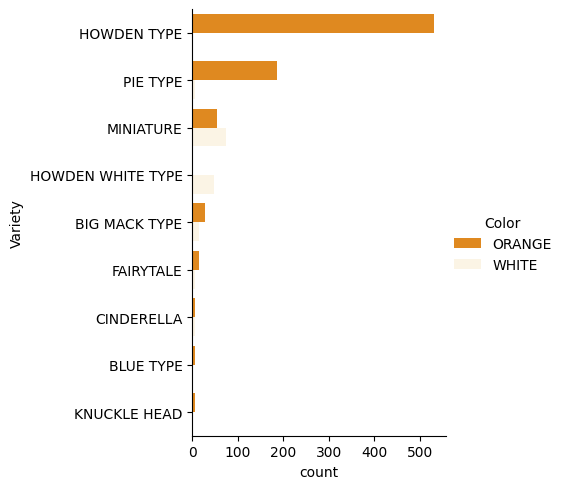

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure consistent capitalization for color values
pumpkins["Color"] = pumpkins["Color"].str.upper()

# Define palette
palette = {
    'ORANGE': '#FF8C00', # bright orange
    'WHITE': '#FFF5E1', # soft white
}

# Sort varieties by frequency
order = pumpkins["Variety"].value_counts().index

# Create plot
sns.catplot(
    data=pumpkins,
    y="Variety",
    hue="Color",
    kind="count",
    palette=palette,
    order=order
)

plt.show()

<span style="color:red;">Question: What are we trying to achieve?</span>



<span style="color:green;">Answer:</span> </br>
We perform the visualization because we can gather information what we cannot achieve just by looking at the data. </br>
In our example, we can instantly see which varieties are mostly orange vs white, and which varieties are more common (in this case "miniture"). </br>

We can also catch issues early, so as an example we included the line. </br>
<span style="color:green;"> pumpkins["Color"] = pumpkins["Color"].str.upper() </span> </br>

for instances where the labels may be inconsistant (example: "Orange" vs "ORANGE"). Data is almost always never perfectly clean, especially coming from sources like .csv and .xlsx. We can also identify missing values and unexpected categories, but for now our categorical plot, it looks ok.

# Data pre-processing

Let's encode features and labels to better plot the data and train the model

In [ ]:
# Compare values of the 'Item Size' column
print(pumpkins['Item Size'].unique())

print('Number of items without a label:', pumpkins['Item Size'].isnull().sum())

['med' 'lge' 'sml' 'xlge' 'med-lge' 'jbo' 'exjbo']
Number of items without a label: 0


<span style="color:red;"> Question: What can we understand from this? </span>

<span style="color:green;">Answer:</span> </br>
We can see that the item size varies between medium to extra-jumbo </br>
Note it is useful to check if there are missing values, as we can see there are none. </br>


<span style="color:green;"> Quick tip:</span> </br>
As a rule we can either delete for fill the missing rows </br>
As we already covered for missing rows prior, we can fill the missing rows with an average value (example: medium). </br>
<span style="color:green;"> pumpkins['Item Size'].fillna('Medium') </span> </br>

We can also use other techniques like taking the most frequent values, etc.

<span style="color:red;">Question: We have three options for encoding, ordinal, label and one-hot, which one should we use in this case?</span>

<span style="color:green;">Answer:</span> </br>
It depends, if we have categorical data which is ordinal, then we should use ordinal encoding. </br>
If there is no natural order, for example if we are trying to encode cities, then one-hot encoding is preferred, so that everything else besides that city is zero. </br>
Label encoding is suitable, as an example, for pumpkin color as it is simple assigning an integer to the color.

Let's encode the item size feature. </br>
we will use from the sklearn library for this, lets import the OrdinalEncoder class from the preprocessing module </br>
this is specifically used (as the name emplies) to encode ordinal data </br>
Can anyone guess the class used for one-hot encoding?

<span style="color:green;"> Answer:</span> OneHotEncoder

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Encode the 'Item Size' column using ordinal encoding
item_size_categories = [['sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo']]
ordinal_features = ['Item Size']
ordinal_encoder = OrdinalEncoder(categories=item_size_categories)

<span style="color:red;">Question: Why did we included 'sml' in our list of size catergories when we did not have it our "item list" column? </span>

<span style="color:green;"> Answer: </span> </br>
it is good practice to include the list of possible catergories in their order. Great for future consistency and the encoder already knows the intended order.

Next we encode all other non-ordinal features

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Encode all the other features using one-hot encoding
categorical_features = ['City Name', 'Package', 'Variety', 'Origin']
categorical_encoder = OneHotEncoder(sparse_output=False)

In [ ]:
from sklearn.preprocessing import FunctionTransformer, LabelEncoder

# Wrap the label encoded 'Color' with FunctionTransformer
## We need this step since LabelEncoder only accepts 1D arrays and ColumnTransformer needs the transformers (ie. your encoders) to work on 2d arrays
## there is a fit step and the transform step, so the label_encode_column must be reshaped
def label_encode_column(col):
    le = LabelEncoder()
    series = col.squeeze()
    encoded = le.fit_transform(series)
    return pd.DataFrame(encoded, columns=['Color'], index=col.index)

label_features = ['Color']
label_encoder = FunctionTransformer(label_encode_column)

After we need to combine all encoded features, ordinal, label and one-hot. the class ColumnTransformer from the compose module is perfect for this, since it allows you to perform different prepcoessing steps to different columns, which is great when having a mix of ordinal and categorical features.

In [ ]:
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(transformers=[
     ('ord', ordinal_encoder, ordinal_features),
     ('cat', categorical_encoder, categorical_features),
     ('lab', label_encoder, label_features)
     ])
# Get the encoded features as a pandas DataFrame
ct.set_output(transform='pandas')
encoded_features = ct.fit_transform(pumpkins)
encoded_features.head()

,ord__Item Size,cat__City Name_ATLANTA,cat__City Name_BALTIMORE,cat__City Name_BOSTON,cat__City Name_CHICAGO,cat__City Name_COLUMBIA,cat__City Name_DALLAS,cat__City Name_DETROIT,cat__City Name_LOS ANGELES,cat__City Name_MIAMI,...,cat__Origin_NEW JERSEY,cat__Origin_NEW YORK,cat__Origin_NORTH CAROLINA,cat__Origin_OHIO,cat__Origin_PENNSYLVANIA,cat__Origin_TENNESSEE,cat__Origin_TEXAS,cat__Origin_VERMONT,cat__Origin_VIRGINIA,lab__Color
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
# Quick check to list all the features
encoded_features.columns.tolist()

['ord__Item Size',
 'cat__City Name_ATLANTA',
 'cat__City Name_BALTIMORE',
 'cat__City Name_BOSTON',
 'cat__City Name_CHICAGO',
 'cat__City Name_COLUMBIA',
 'cat__City Name_DALLAS',
 'cat__City Name_DETROIT',
 'cat__City Name_LOS ANGELES',
 'cat__City Name_MIAMI',
 'cat__City Name_NEW YORK',
 'cat__City Name_PHILADELPHIA',
 'cat__City Name_SAN FRANCISCO',
 'cat__City Name_ST. LOUIS',
 'cat__Package_1 1/9 bushel cartons',
 'cat__Package_1 1/9 bushel crates',
 'cat__Package_1/2 bushel cartons',
 'cat__Package_24 inch bins',
 'cat__Package_36 inch bins',
 'cat__Package_bins',
 'cat__Package_bushel cartons',
 'cat__Variety_BIG MACK TYPE',
 'cat__Variety_BLUE TYPE',
 'cat__Variety_CINDERELLA',
 'cat__Variety_FAIRYTALE',
 'cat__Variety_HOWDEN TYPE',
 'cat__Variety_HOWDEN WHITE TYPE',
 'cat__Variety_KNUCKLE HEAD',
 'cat__Variety_MINIATURE',
 'cat__Variety_PIE TYPE',
 'cat__Origin_ALABAMA',
 'cat__Origin_CALIFORNIA',
 'cat__Origin_CANADA',
 'cat__Origin_DELAWARE',
 'cat__Origin_ILLINOIS',
 'ca

# Analysing relationships between features and label

We will use seaborn plotting functions to understand their relationships </br>
The first instance is we will use catagorical plots to create a high level interface (easier to see differences and patterns)</br>
The second instance we use the swarm plot (named after a swarm of insects). The points are spread out so they don't overlap, the error message below simply states that there is some overlap. </br>
The third instance we strip plot (strip of points along a line). Similar to the swarm plot, just that there is overlap.

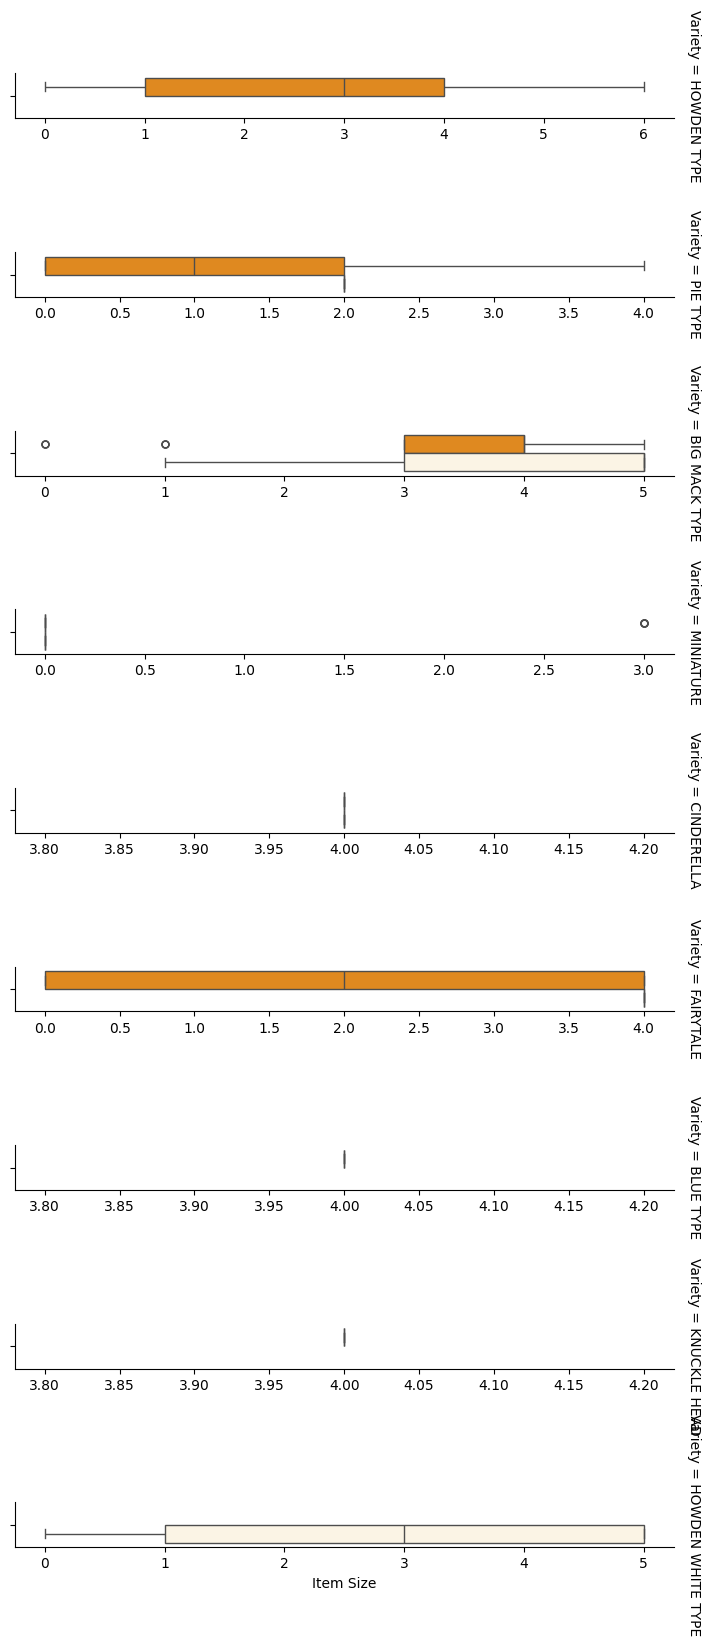

In [ ]:
palette = {
    0: '#FF8C00',  # ORANGE
    1: '#FFF5E1'   # WHITE
}

g = sns.catplot(
    data=pumpkins,
    x="Item Size",
    hue="Color",
    row='Variety',
    kind="box",
    orient="h",
    sharex=False,
    margin_titles=True,
    height=1.8,
    aspect=4,
    palette=palette,
    legend=False
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 73.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 30.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 79.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 35.9% of the points cannot be placed; you may want to decrease the size of the markers or use s

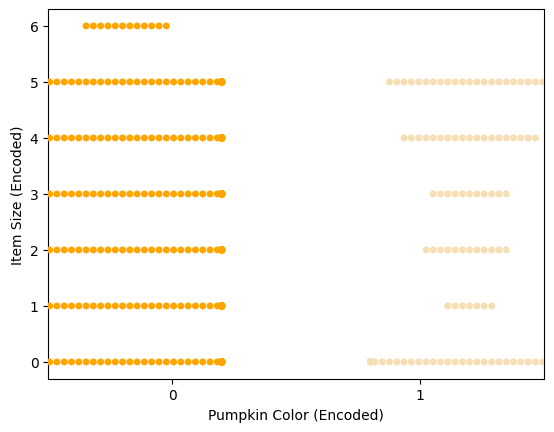

In [ ]:
sns.swarmplot(
    x="lab__Color",
    y="ord__Item Size",
    hue="lab__Color",
    data=encoded_features,
    palette={0:'orange', 1:'wheat'},
    dodge=True,
    legend=False
)

plt.xlabel("Pumpkin Color (Encoded)")
plt.ylabel("Item Size (Encoded)")
plt.show()

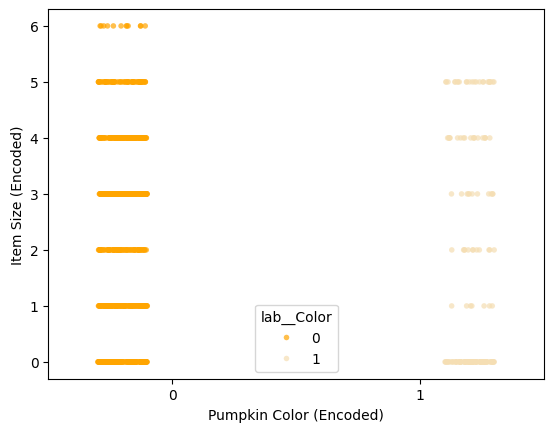

In [ ]:
# Plot using stripplot
sns.stripplot(
    x="lab__Color",                 # numeric encoded color
    y="ord__Item Size",
    hue="lab__Color",                # human-readable hue
    data=encoded_features,          # must be the same DF that has Color_str
    palette={0:'orange', 1:'wheat'},
    dodge=True,
    jitter=0.2,
    size=4,
    alpha=0.7
)

plt.xlabel("Pumpkin Color (Encoded)")
plt.ylabel("Item Size (Encoded)")
plt.show()

# Build your model </br>

First we would like to declare the features and the target, and then split the train and test sets 80/20

In [ ]:
from sklearn.model_selection import train_test_split

# X is the encoded features
X = encoded_features.drop(columns=['lab__Color', 'Color_str'])
y = encoded_features['lab__Color']
# y is the encoded label
y = encoded_features['lab__Color']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Accuracy: 0.925
Weighted F1 Score: 0.921

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       166
           1       0.85      0.67      0.75        33

    accuracy                           0.92       199
   macro avg       0.89      0.82      0.85       199
weighted avg       0.92      0.92      0.92       199

Confusion Matrix:
[[162   4]
 [ 11  22]]


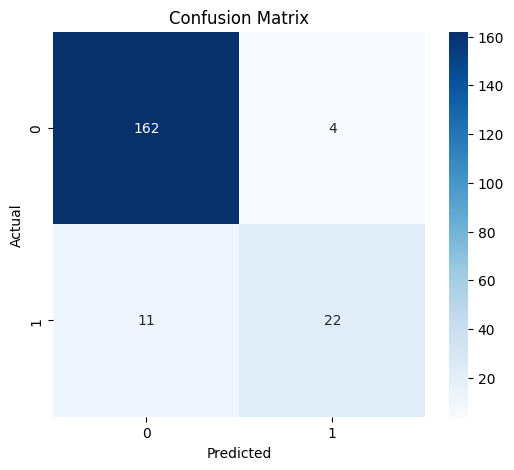

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train the logistic regression model
model = LogisticRegression(max_iter=1000)  # ensure convergence
model.fit(X_train, y_train)

# Make predictions on the test set
predictions = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, predictions)
print(f"Accuracy: {acc:.3f}")

# F1 score (weighted to account for class imbalance)
f1 = f1_score(y_test, predictions, average='weighted')
print(f"Weighted F1 Score: {f1:.3f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Confusion matrix
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(cm)

# Optional: visualizing the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

<span style="color:red;"> Question: What do these results mean? </span>

<span style="color:red;">Hints: </span></br>
Accuracy = Number of correct predictions / Total number of predictions </br>
F1 score = 2 * (precision * recall) / (precision + recall) </br>

Classification report:</br>
Contains the f1 score, precision, recall and support (number of actual samples) for the classes. as well as the classes weighted and macro (simple) scores.


<span style="color:green;"> Answer: </span></br>
Accuracy: 0.925 </br>
This implies a strong performance of the model

Weighted F1 score: 0.921 </br>
This is consistant with accuracy, so it is well balanced

<span style="color:red;"> Question: What about the indiviual classes F1 scores, what can we learn from it?</span>

<span style="color:green;"> Answer: </span></br>
High F1 score for Class 0. It means that the model is great at identifying pumpkins of the majority color. </br>
Lower F1 score for Class 1. Model struggles with the minority class. Recall is lower so the model misses a significant number of Class 1 pumpkins. Lower precision means that some predictions are incorrect. </br>

<span style="color:green;">Why: </span></br>
The dataset is imbalanced, the model is baised to the majority class because it sees it more during training. this is normal in logistic regression without class weighting or oversampling. </br>
<span style="color:green;">Takeaway: </span></br>
Model is more reliable for majority classes but less so for minority classes.

<span style="color:red;">Question: If the Accuracy and F1 Score are similar in that the compare predictions, what separates them?  </span></br>

Hint: The F1 score also containes the recall (think about how the classes are balanced or imbalanced)

<span style="color:green;"> Answer: </span></br>
Accuracy is better when the classes are balanced and that the errors are equally important, with the F1 score we care more about the false positives and false negatives and is better when the classes are imbalanced. </br>
F1 score focuses on class-specfifc errors, accuracy gives a gloabl error rate. F1 score is more sensitive to minortiy-class errors.


Confusion matrix, without normalization
[[162   4]
 [ 11  22]]
Normalized confusion matrix
[[0.97590361 0.02409639]
 [0.33333333 0.66666667]]


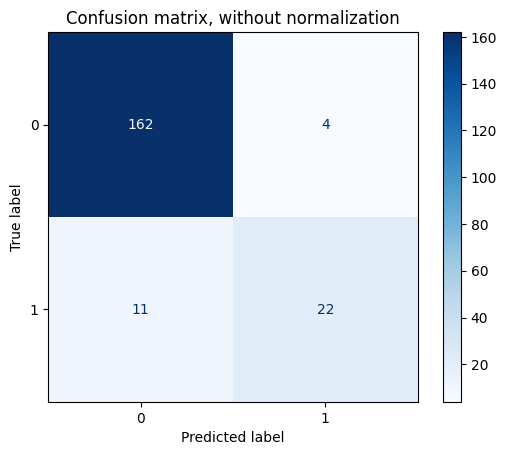

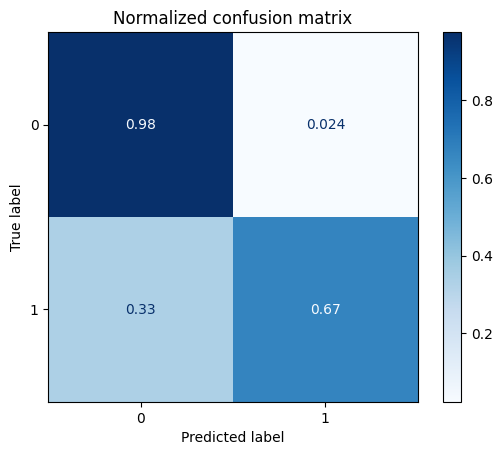

In [ ]:
# Confusion Matrix vs Normalised Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

class_names = {'0': 'Orange', '1':'White'}
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

The normalised confusion matrix explains the proportion of correct and incorect predictions for each class. It highlights class-wise performance. For example, if one row has low values on the diagonal, that class is being misclassified a lot. So it helps detect class imbalance effects, because the normalization removes the influence of class counts.

# the ROC curve (receiver Operating Characteristic curve) and the ROC AUC Score

The ROC Curve is a simple graphical represention of the classification model performance across all possible thresholds. </br>
The ROC AUC Score is the area under the ROc curve that summaries the ROC curve.

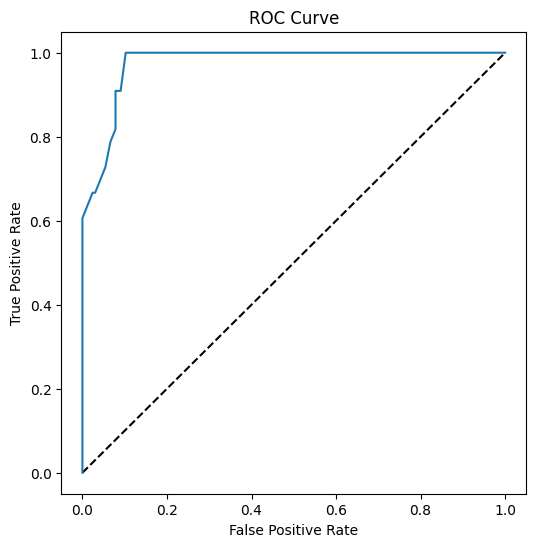

0.9749908725812341


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_scores = model.predict_proba(X_test)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

# Plot ROC curve
fig = plt.figure(figsize=(6, 6))
# Plot the diagonal 50% line
plt.plot([0, 1], [0, 1], 'k--')
# Plot the FPR and TPR achieved by our model
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

auc = roc_auc_score(y_test,y_scores[:,1])
print(auc)

The curve depicts the True Positive Rate vs the False Positive Rate </br>

Generally if the curve is to the top left it is a better classifier, if it approaches the halfway line the model performs poorly. Once it crosses the line, then the model performs worse than random. </br>

The AUC Score summaries this figure. So generally: </br>
1.0 is a perfect classifier </br>
0.5 it is randomly guessing </br>
<0.5 it is performing worse than random